In [1]:
import boto3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [4]:
bucket_name = "dsan6000-vt216"
prefix = "wikipedia-hourly/"

s3 = boto3.client("s3")

In [5]:
response = s3.list_objects_v2(
    Bucket=bucket_name,
    Prefix=prefix
)

keys = [
    obj["Key"]
    for obj in response["Contents"]
    if obj["Key"].endswith(".parquet")
]

len(keys)

24

In [6]:
dfs = []

for key in keys:
    uri = f"s3://{bucket_name}/{key}"
    hour_df = pd.read_parquet(uri)
    dfs.append(hour_df)

df = pd.concat(dfs, ignore_index=True)

In [7]:
print(df.head())
df.columns

              datetime                        $schema  \
0  2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
1  2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
2  2026-09-01 04:00:01  /mediawiki/recentchange/1.0.0   
3  2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
4  2026-09-01 04:00:03  /mediawiki/recentchange/1.0.0   

                                                meta            id  type  \
0  {'uri': 'https://en.wikipedia.org/wiki/Jake_O%...  2.063884e+09  edit   
1  {'uri': 'https://en.wikipedia.org/wiki/Beverid...  2.063884e+09  edit   
2  {'uri': 'https://en.wikipedia.org/wiki/1920_Un...  2.063884e+09  edit   
3  {'uri': 'https://en.wikipedia.org/wiki/1987_Ae...  2.063884e+09  edit   
4  {'uri': 'https://en.wikipedia.org/wiki/Marvin_...  2.063884e+09  edit   

   namespace                                              title  \
0          0                                     Jake O'Donnell   
1          0                                    Beveridge Award   

Index(['datetime', '$schema', 'meta', 'id', 'type', 'namespace', 'title',
       'title_url', 'comment', 'timestamp', 'user', 'bot', 'notify_url',
       'minor', 'length', 'revision', 'server_url', 'server_name',
       'server_script_path', 'wiki', 'parsedcomment', 'log_id', 'log_type',
       'log_action', 'log_params', 'log_action_comment', 'patrolled',
       'file_ts', 'file_ts_str'],
      dtype='str')

In [9]:
df["datetime"] = pd.to_datetime(df["datetime"])

df["hour"] = df["datetime"].dt.floor("h")

hourly_counts = (
    df.groupby("hour")
      .size()
      .reset_index(name="event_count")
)

hourly_counts.head()

,hour,event_count
0,2026-09-01 04:00:00,4458
1,2026-09-01 05:00:00,3769
2,2026-09-01 06:00:00,3981
3,2026-09-01 07:00:00,3186
4,2026-09-01 08:00:00,3519


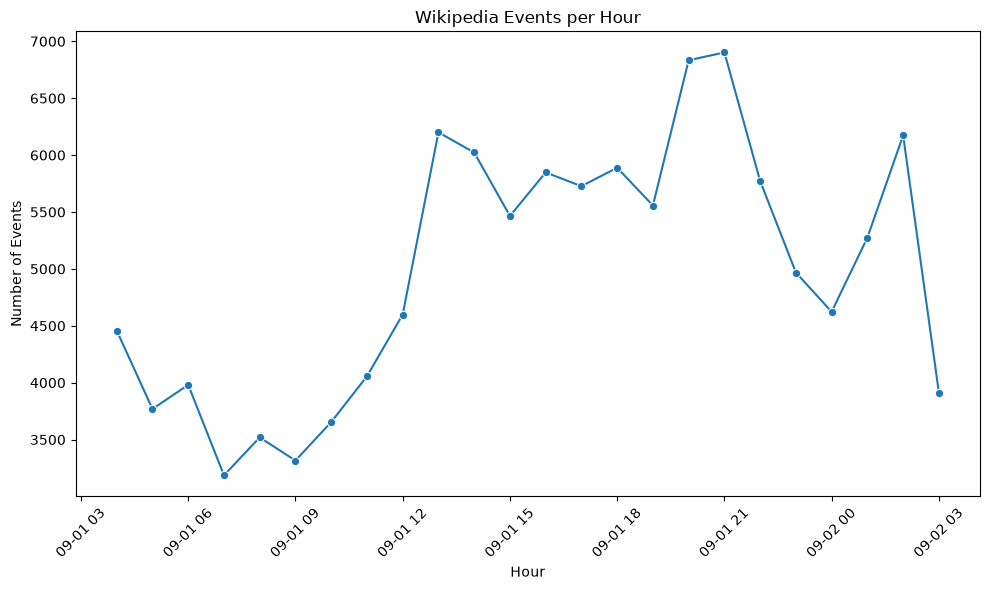

In [10]:
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=hourly_counts,
    x="hour",
    y="event_count",
    marker="o"
)

plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.title("Wikipedia Events per Hour")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("images/hourly-events.png")
plt.savefig("images/hourly-events.svg")
plt.show()

In [11]:
hourly_type_counts = (
    df.groupby(["hour", "type"])
      .size()
      .reset_index(name="event_count")
)

hourly_type_counts.head()

,hour,type,event_count
0,2026-09-01 04:00:00,edit,3959
1,2026-09-01 04:00:00,log,440
2,2026-09-01 04:00:00,new,59
3,2026-09-01 05:00:00,edit,3429
4,2026-09-01 05:00:00,log,199


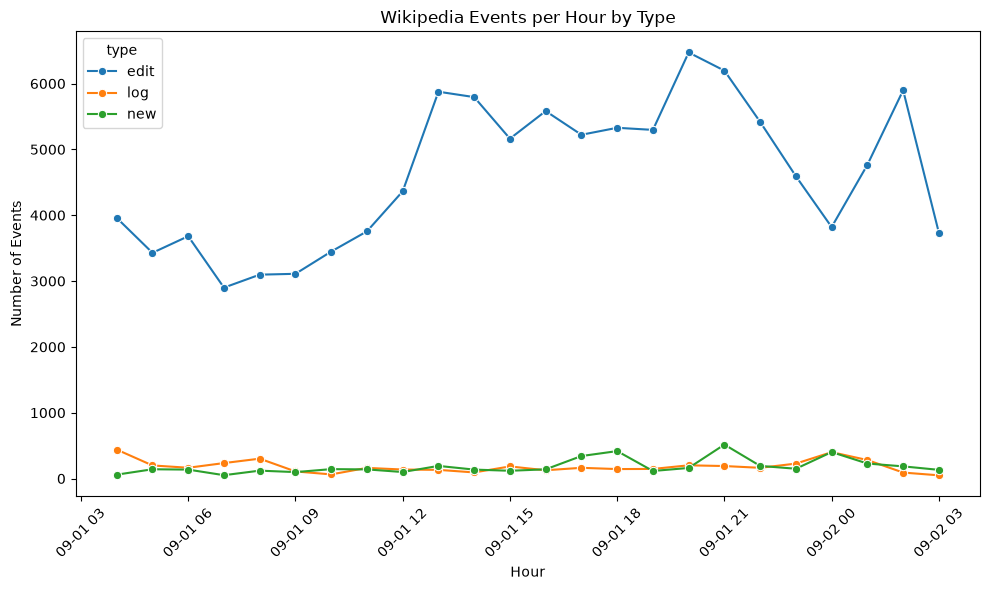

In [12]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=hourly_type_counts,
    x="hour",
    y="event_count",
    hue="type",
    marker="o"
)

plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.title("Wikipedia Events per Hour by Type")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("images/events-by-type.png")
plt.savefig("images/events-by-type.svg")
plt.show()

In [13]:
os.listdir("images")

['vscode-kernel.jpeg',
 'hourly-events.svg',
 'events-by-type.svg',
 'events-by-type.png',
 'hourly-events.png',
 'vscode-connected.jpeg']